<a href="https://colab.research.google.com/github/Panashe-2/Smart_farming/blob/main/Maize_Suitability_model1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import( accuracy_score,
                            classification_report,
                             confusion_matrix)

In [5]:
data=pd.read_csv("/content/One_Acre_Fund_MEL_maize_survey_data_2016-2022.csv")
print(data.head())

   year     lon    lat         strat  avg_season_gdd  avg_season_ai  \
0  2016  34.067  0.227  01_KEN7701S1     2509.099854       0.998492   
1  2017  34.100  0.240  01_KEN7701S1     2552.900146       1.038017   
2  2019  34.082  0.247  01_KEN7701S1     2580.099854       1.008526   
3  2020  34.098  0.232  01_KEN7701S1     2562.800049       1.018445   
4  2020  34.094  0.274  01_KEN7701S1     2612.800049       1.023641   

   avg_season_tavg  season_prec  season_prec_1  season_prec_2  ...  manure  \
0        21.275661   677.039708     228.759519     365.227443  ...     NaN   
1        21.507408   760.532583     154.624451     464.134379  ...     NaN   
2        21.651323   724.153837     181.676820     359.354439  ...     NaN   
3        21.559790   998.342599     379.451999     428.776234  ...    True   
4        21.824339   998.342599     379.451999     428.776234  ...     NaN   

   fert_in_hole  lime_kg_ha  weeding  pesticide  disease   pest  striga  \
0          TRUE         0.0  

In [6]:
data.shape

(6095, 46)

In [7]:
data.columns.tolist()

['year',
 'lon',
 'lat',
 'strat',
 'avg_season_gdd',
 'avg_season_ai',
 'avg_season_tavg',
 'season_prec',
 'season_prec_1',
 'season_prec_2',
 'season_prec_3',
 'elev',
 'twi',
 'soil_rzpawhc',
 'soil_clay',
 'soil_pH',
 'soil_orgC',
 'soil_ECEC',
 'plant_date_dev',
 'pl_m2',
 'row_spacing',
 'hybrid',
 'hyb_type',
 'hyb_mat',
 'hyb_yor',
 'hyb_tol_mln',
 'hyb_tol_msv',
 'hyb_tol_gls',
 'hyb_tol_nclb',
 'hyb_tol_rust',
 'hyb_tol_ear_rot',
 'N_kg_ha',
 'P_kg_ha',
 'K_kg_ha',
 'compost',
 'comp_kg_ha',
 'manure',
 'fert_in_hole',
 'lime_kg_ha',
 'weeding',
 'pesticide',
 'disease',
 'pest',
 'striga',
 'water_excess',
 'yield_kg_ha']

In [8]:
data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6095 entries, 0 to 6094
Data columns (total 46 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   year             6095 non-null   int64  
 1   lon              6095 non-null   float64
 2   lat              6095 non-null   float64
 3   strat            6095 non-null   object 
 4   avg_season_gdd   6095 non-null   float64
 5   avg_season_ai    6095 non-null   float64
 6   avg_season_tavg  6095 non-null   float64
 7   season_prec      6095 non-null   float64
 8   season_prec_1    6095 non-null   float64
 9   season_prec_2    6095 non-null   float64
 10  season_prec_3    6095 non-null   float64
 11  elev             6095 non-null   int64  
 12  twi              6095 non-null   float64
 13  soil_rzpawhc     5330 non-null   float64
 14  soil_clay        5330 non-null   float64
 15  soil_pH          5330 non-null   float64
 16  soil_orgC        5330 non-null   float64
 17  soil_ECEC     

In [9]:
data.dtypes

,0
year,int64
lon,float64
lat,float64
strat,object
avg_season_gdd,float64
avg_season_ai,float64
avg_season_tavg,float64
season_prec,float64
season_prec_1,float64
season_prec_2,float64


In [10]:
data.isnull().sum()

,0
year,0
lon,0
lat,0
strat,0
avg_season_gdd,0
avg_season_ai,0
avg_season_tavg,0
season_prec,0
season_prec_1,0
season_prec_2,0


In [11]:
#percentage of missing values in each column
missing_values_percentage = (data.isnull().sum() / len(data)) * 100
print(missing_values_percentage)

year                0.000000
lon                 0.000000
lat                 0.000000
strat               0.000000
avg_season_gdd      0.000000
avg_season_ai       0.000000
avg_season_tavg     0.000000
season_prec         0.000000
season_prec_1       0.000000
season_prec_2       0.000000
season_prec_3       0.000000
elev                0.000000
twi                 0.000000
soil_rzpawhc       12.551272
soil_clay          12.551272
soil_pH            12.551272
soil_orgC          12.551272
soil_ECEC          12.551272
plant_date_dev     20.639869
pl_m2              33.043478
row_spacing        49.433962
hybrid              3.806399
hyb_type           68.859721
hyb_mat            31.763741
hyb_yor            36.603774
hyb_tol_mln        33.847416
hyb_tol_msv        33.847416
hyb_tol_gls        33.847416
hyb_tol_nclb       33.847416
hyb_tol_rust       33.847416
hyb_tol_ear_rot    33.847416
N_kg_ha             0.000000
P_kg_ha             0.000000
K_kg_ha            13.913043
compost       

In [12]:
data.duplicated().sum()

np.int64(0)

In [13]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
year,6095.0,2018.111075,1.515471,2016.000000,2017.000000,2018.000000,2020.000000,2020.000000
lon,6095.0,34.776323,0.449399,34.059000,34.454500,34.678000,34.932000,35.868000
lat,6095.0,-1.151276,2.805095,-7.988000,-0.826500,0.023000,0.392000,1.167000
avg_season_gdd,6095.0,2175.206201,417.724068,1249.500000,1958.199951,2315.899902,2483.699951,2717.199951
avg_season_ai,6095.0,1.249254,0.162300,0.832935,1.146551,1.244748,1.374478,1.667799
avg_season_tavg,6095.0,20.238410,1.212775,16.705820,19.537169,20.283068,21.170898,23.117392
season_prec,6095.0,972.400952,207.746342,510.000865,811.909999,924.573741,1114.649177,1653.269439
season_prec_1,6095.0,324.333094,147.109092,53.998493,175.683775,326.427233,424.037194,683.582937
season_prec_2,6095.0,435.709604,77.791476,185.093431,382.501603,437.217441,485.251162,720.638906
season_prec_3,6095.0,212.358255,119.919863,0.000000,136.380944,222.653805,295.321153,580.918544


In [14]:
#FINDING THE MAIZE YIELD COLUMN
[col for col in data.columns if "yield" in col.lower()]

['yield_kg_ha']

In [15]:
data[[col for col in data.columns if "yield" in col.lower()]].describe()

,yield_kg_ha
count,6094.000000
mean,2807.707230
std,1525.511402
min,0.000000
25%,1725.298822
50%,2581.791294
75%,3676.460187
max,9754.051924


In [16]:
# environmental variables
[col for col in data.columns
 if any(x in col.lower() for x in ["soil", "ph", "clay", "orgc", "ecec"])]

['soil_rzpawhc', 'soil_clay', 'soil_pH', 'soil_orgC', 'soil_ECEC']

In [17]:
#Fertilizer variables
[col for col in data.columns
 if any(x in col.lower() for x in ["n_", "p_", "k_", "fert", "manure", "compost"])]

['avg_season_gdd',
 'avg_season_ai',
 'avg_season_tavg',
 'season_prec',
 'season_prec_1',
 'season_prec_2',
 'season_prec_3',
 'N_kg_ha',
 'P_kg_ha',
 'K_kg_ha',
 'compost',
 'comp_kg_ha',
 'manure',
 'fert_in_hole']

In [18]:
#features
features = [
    "avg_season_gdd",
    "avg_season_ai",
    "avg_season_tavg",
    "season_prec",
    "season_prec_1",
    "season_prec_2",
    "season_prec_3",
    "elev",
    "twi",
    "soil_rzpawhc",
    "soil_clay",
    "soil_pH",
    "soil_orgC",
    "soil_ECEC",
    "N_kg_ha",
    "P_kg_ha",
    "K_kg_ha",
    "lime_kg_ha"
]

In [19]:
data["yield_kg_ha"].describe()

,yield_kg_ha
count,6094.000000
mean,2807.707230
std,1525.511402
min,0.000000
25%,1725.298822
50%,2581.791294
75%,3676.460187
max,9754.051924


<Axes: >

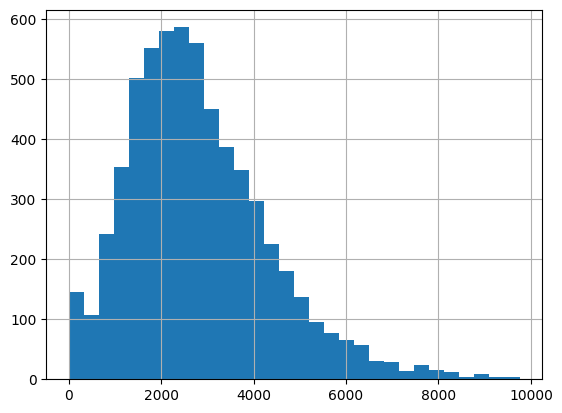

In [20]:
data["yield_kg_ha"].hist(bins=30)

In [21]:
data["yield_kg_ha"].sort_values().head(20)

,yield_kg_ha
928,0.0
11,0.0
1032,0.0
1040,0.0
5256,0.0
5257,0.0
4993,0.0
2,0.0
1653,0.0
1953,0.0


In [22]:
data["yield_kg_ha"].sort_values(ascending=False).head(20)

,yield_kg_ha
1034,9754.051924
3772,9668.200000
4172,9645.370721
1293,9563.860786
6003,9278.575891
6066,9163.102052
1057,9115.554811
3093,9095.741044
3271,9052.488901
5965,9006.691846


In [23]:
 #zero yield fields
 (data["yield_kg_ha"]==0)

,yield_kg_ha
0,False
1,False
2,True
3,False
4,False
...,...
6090,False
6091,False
6092,False
6093,False


In [24]:
#percentage of zero yield fields
(data["yield_kg_ha"] == 0).mean() * 100

np.float64(1.7391304347826086)

In [25]:
#yield distribution by quartile
data["yield_kg_ha"].quantile([0, 0.10, 0.25, 0.50, 0.75, 0.90, 1.00])

,yield_kg_ha
0.00,0.000000
0.10,1107.179882
0.25,1725.298822
0.50,2581.791294
0.75,3676.460187
0.90,4806.430385
1.00,9754.051924


In [26]:
#yield against average temperature
data[["avg_season_tavg", "yield_kg_ha"]].corr()


,avg_season_tavg,yield_kg_ha
avg_season_tavg,1.000000,-0.141631
yield_kg_ha,-0.141631,1.000000


In [27]:
#yield against rainfall
data[["season_prec", "yield_kg_ha"]].corr()

,season_prec,yield_kg_ha
season_prec,1.000000,0.090868
yield_kg_ha,0.090868,1.000000


In [28]:
#yeild gainst pH
data[["soil_pH", "yield_kg_ha"]].corr()

,soil_pH,yield_kg_ha
soil_pH,1.000000,-0.077846
yield_kg_ha,-0.077846,1.000000


In [29]:
#yield against fertilizer application
data[[
    "N_kg_ha",
    "P_kg_ha",
    "K_kg_ha",
    "yield_kg_ha"
]].corr()

,N_kg_ha,P_kg_ha,K_kg_ha,yield_kg_ha
N_kg_ha,1.000000,0.737628,0.018064,0.178299
P_kg_ha,0.737628,1.000000,0.063604,0.183848
K_kg_ha,0.018064,0.063604,1.000000,-0.005098
yield_kg_ha,0.178299,0.183848,-0.005098,1.000000


In [30]:
zero_yield = (data["yield_kg_ha"] == 0).sum()

print("Zero-yield observations:", zero_yield)
print("Percentage:", zero_yield / len(data) * 100)

Zero-yield observations: 106
Percentage: 1.7391304347826086


In [31]:
important_columns = [
    "avg_season_gdd",
    "avg_season_ai",
    "avg_season_tavg",
    "season_prec",
    "season_prec_1",
    "season_prec_2",
    "season_prec_3",
    "soil_rzpawhc",
    "soil_clay",
    "soil_pH",
    "soil_orgC",
    "soil_ECEC",
    "N_kg_ha",
    "P_kg_ha",
    "K_kg_ha",
    "lime_kg_ha",
    "yield_kg_ha"
]

data[important_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
avg_season_gdd,6095.0,2175.206201,417.724068,1249.500000,1958.199951,2315.899902,2483.699951,2717.199951
avg_season_ai,6095.0,1.249254,0.162300,0.832935,1.146551,1.244748,1.374478,1.667799
avg_season_tavg,6095.0,20.238410,1.212775,16.705820,19.537169,20.283068,21.170898,23.117392
season_prec,6095.0,972.400952,207.746342,510.000865,811.909999,924.573741,1114.649177,1653.269439
season_prec_1,6095.0,324.333094,147.109092,53.998493,175.683775,326.427233,424.037194,683.582937
season_prec_2,6095.0,435.709604,77.791476,185.093431,382.501603,437.217441,485.251162,720.638906
season_prec_3,6095.0,212.358255,119.919863,0.000000,136.380944,222.653805,295.321153,580.918544
soil_rzpawhc,5330.0,108.041576,38.509317,0.800000,103.500000,120.000000,135.000000,165.000000
soil_clay,5330.0,39.089306,5.231146,20.000000,37.000000,40.000000,43.000000,51.000000
soil_pH,5330.0,5.641895,0.214503,5.000000,5.500000,5.600000,5.800000,6.600000


In [32]:
data[important_columns].isnull().sum()

,0
avg_season_gdd,0
avg_season_ai,0
avg_season_tavg,0
season_prec,0
season_prec_1,0
season_prec_2,0
season_prec_3,0
soil_rzpawhc,765
soil_clay,765
soil_pH,765


In [33]:
data[important_columns].corr()["yield_kg_ha"].sort_values(ascending=False)

,yield_kg_ha
yield_kg_ha,1.000000
P_kg_ha,0.183848
N_kg_ha,0.178299
season_prec_3,0.135862
soil_orgC,0.118358
soil_ECEC,0.093010
season_prec,0.090868
soil_clay,0.073598
avg_season_ai,0.057117
lime_kg_ha,0.043270


In [34]:
soil_cols = [
    "soil_rzpawhc",
    "soil_clay",
    "soil_pH",
    "soil_orgC",
    "soil_ECEC"
]

data[soil_cols].isnull().groupby(
    data["yield_kg_ha"] > 2000
).mean()

,soil_rzpawhc,soil_clay,soil_pH,soil_orgC,soil_ECEC
yield_kg_ha,,,,,
False,0.155622,0.155622,0.155622,0.155622,0.155622
True,0.110894,0.110894,0.110894,0.110894,0.110894


In [35]:
data[soil_cols].isnull().all(axis=1).value_counts()

,count
False,5330
True,765


In [36]:
data["soil_pH"].isnull().groupby(data["yield_kg_ha"]).mean().head(20)

,soil_pH
yield_kg_ha,
0.000000,0.311321
14.943532,0.000000
40.755089,0.000000
55.698621,0.000000
69.967243,0.000000
74.717662,0.000000
120.852500,0.000000
122.265263,0.000000
135.850300,0.000000


In [37]:
data["suitability"] = ...

In [38]:
data["suitability"].value_counts()

,count
suitability,
Ellipsis,6095


In [39]:
# Check missing values in the variables we may use for Model 1

features_to_check = [
    "avg_season_gdd",
    "avg_season_ai",
    "avg_season_tavg",
    "season_prec",
    "season_prec_1",
    "season_prec_2",
    "season_prec_3",
    "elev",
    "twi",
    "soil_rzpawhc",
    "soil_clay",
    "soil_pH",
    "soil_orgC",
    "soil_ECEC",
    "N_kg_ha",
    "P_kg_ha",
    "K_kg_ha",
    "lime_kg_ha"
]

missing = data[features_to_check].isnull().sum()

missing_percentage = (missing / len(data)) * 100

missing_table = pd.DataFrame({
    "Missing Values": missing,
    "Missing Percentage": missing_percentage
}).sort_values("Missing Percentage", ascending=False)

missing_table

,Missing Values,Missing Percentage
K_kg_ha,848,13.913043
soil_rzpawhc,765,12.551272
soil_pH,765,12.551272
soil_ECEC,765,12.551272
soil_clay,765,12.551272
soil_orgC,765,12.551272
lime_kg_ha,47,0.771124
avg_season_gdd,0,0.000000
avg_season_ai,0,0.000000
avg_season_tavg,0,0.000000


In [40]:
features = [
    "avg_season_gdd",
    "avg_season_ai",
    "avg_season_tavg",
    "season_prec",
    "season_prec_1",
    "season_prec_2",
    "season_prec_3",
    "elev",
    "twi",
    "soil_rzpawhc",
    "soil_clay",
    "soil_pH",
    "soil_orgC",
    "soil_ECEC",
    "N_kg_ha",
    "P_kg_ha"
]

In [41]:
features = [
    "avg_season_gdd",
    "avg_season_ai",
    "avg_season_tavg",
    "season_prec",
    "season_prec_1",
    "season_prec_2",
    "season_prec_3",
    "elev",
    "twi",
    "soil_rzpawhc",
    "soil_clay",
    "soil_pH",
    "soil_orgC",
    "soil_ECEC",
    "N_kg_ha",
    "P_kg_ha"
]

# rows with all required features available
model_data = data[features + ["yield_kg_ha"]].dropna()

print("Original rows:", len(data))
print("Rows available for modelling:", len(model_data))
print("Rows removed:", len(data) - len(model_data))

Original rows: 6095
Rows available for modelling: 5329
Rows removed: 766


In [42]:
# Check the yield distribution in the actual modelling dataset
model_data["yield_kg_ha"].describe()

,yield_kg_ha
count,5329.000000
mean,2854.220637
std,1546.325168
min,0.000000
25%,1766.053790
50%,2639.672390
75%,3727.345374
max,9754.051924


In [43]:
#Testing the proposed suitability thresholds

model_data["suitability"] = pd.cut(
    model_data["yield_kg_ha"],
    bins=[-float("inf"), 1000, 2000, float("inf")],
    labels=[
        "Unsuitable",
        "Moderately Suitable",
        "Suitable"
    ]
)

print(model_data["suitability"].value_counts())
print()
print(model_data["suitability"].value_counts(normalize=True) * 100)

suitability
Suitable               3648
Moderately Suitable    1222
Unsuitable              459
Name: count, dtype: int64

suitability
Suitable               68.455620
Moderately Suitable    22.931132
Unsuitable              8.613248
Name: proportion, dtype: float64


In [44]:
# the suitability target

model_data["suitability"] = pd.cut(
    model_data["yield_kg_ha"],
    bins=[-float("inf"), 1000, 2000, float("inf")],
    labels=[
        "Unsuitable",
        "Moderately Suitable",
        "Suitable"
    ]
)

# the result
print(model_data[["yield_kg_ha", "suitability"]].head(10))

   yield_kg_ha          suitability
0  1462.951369  Moderately Suitable
1  2817.771269             Suitable
2     0.000000           Unsuitable
3  4788.722787             Suitable
4  2193.982268             Suitable
5  6227.084346             Suitable
6  1024.065968  Moderately Suitable
7  3822.755280             Suitable
8  1291.213513  Moderately Suitable
9  1558.361131  Moderately Suitable


In [45]:
print(model_data["suitability"].value_counts())

suitability
Suitable               3648
Moderately Suitable    1222
Unsuitable              459
Name: count, dtype: int64


In [46]:
# Input features
X = model_data[features]

# Target
y = model_data["suitability"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (5329, 16)
y shape: (5329,)


In [47]:
print(X.head())
print()
print(y.head())

   avg_season_gdd  avg_season_ai  avg_season_tavg  season_prec  season_prec_1  \
0     2509.099854       0.998492        21.275661   677.039708     228.759519   
1     2552.900146       1.038017        21.507408   760.532583     154.624451   
2     2580.099854       1.008526        21.651323   724.153837     181.676820   
3     2562.800049       1.018445        21.559790   998.342599     379.451999   
4     2612.800049       1.023641        21.824339   998.342599     379.451999   

   season_prec_2  season_prec_3  elev        twi  soil_rzpawhc  soil_clay  \
0     365.227443      83.052746  1280   8.322142         120.0       34.0   
1     464.134379     141.773752  1288  10.117007         120.0       38.0   
2     359.354439     183.122578  1243   7.909871         120.0       33.0   
3     428.776234     190.114366  1271   8.969049         120.0       32.0   
4     428.776234     190.114366  1226   6.008638         120.0       33.0   

   soil_pH  soil_orgC  soil_ECEC    N_kg_ha   P_kg

In [48]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 4263
Testing samples: 1066


In [49]:
print("Training class distribution:")
print(y_train.value_counts())
print()

print("Testing class distribution:")
print(y_test.value_counts())

Training class distribution:
suitability
Suitable               2918
Moderately Suitable     978
Unsuitable              367
Name: count, dtype: int64

Testing class distribution:
suitability
Suitable               730
Moderately Suitable    244
Unsuitable              92
Name: count, dtype: int64


In [50]:
class_weight="balanced"

In [51]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=300,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

print("Random Forest training completed.")

Random Forest training completed.


In [52]:
# predictions on the test data

y_pred = rf_model.predict(X_test)

print("Predictions completed.")
print(y_pred[:10])

Predictions completed.
['Suitable' 'Suitable' 'Moderately Suitable' 'Suitable' 'Suitable'
 'Suitable' 'Suitable' 'Suitable' 'Suitable' 'Suitable']


In [53]:
print("Predicted class distribution:")
print(pd.Series(y_pred).value_counts())

Predicted class distribution:
Suitable               974
Moderately Suitable     78
Unsuitable              14
Name: count, dtype: int64


In [54]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print()

# Detailed classification report
print("Classification Report:")
print(
    classification_report(
        y_test,
        y_pred,
        labels=[
            "Unsuitable",
            "Moderately Suitable",
            "Suitable"
        ],
        zero_division=0
    )
)

# Confusion matrix
cm = confusion_matrix(
    y_test,
    y_pred,
    labels=[
        "Unsuitable",
        "Moderately Suitable",
        "Suitable"
    ]
)

print("Confusion Matrix:")
print(cm)

Accuracy: 0.6829268292682927

Classification Report:
                     precision    recall  f1-score   support

         Unsuitable       0.57      0.09      0.15        92
Moderately Suitable       0.35      0.11      0.17       244
           Suitable       0.71      0.95      0.81       730

           accuracy                           0.68      1066
          macro avg       0.54      0.38      0.38      1066
       weighted avg       0.62      0.68      0.61      1066

Confusion Matrix:
[[  8  14  70]
 [  6  27 211]
 [  0  37 693]]


In [55]:
import pandas as pd

feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf_model.feature_importances_
}).sort_values(
    "Importance",
    ascending=False
)

print(feature_importance)

            Feature  Importance
14          N_kg_ha    0.087996
8               twi    0.085323
7              elev    0.077000
6     season_prec_3    0.073550
1     avg_season_ai    0.072590
5     season_prec_2    0.071110
0    avg_season_gdd    0.065593
4     season_prec_1    0.065516
3       season_prec    0.065403
15          P_kg_ha    0.064249
2   avg_season_tavg    0.063625
10        soil_clay    0.056636
11          soil_pH    0.041413
9      soil_rzpawhc    0.040448
12        soil_orgC    0.036356
13        soil_ECEC    0.033192


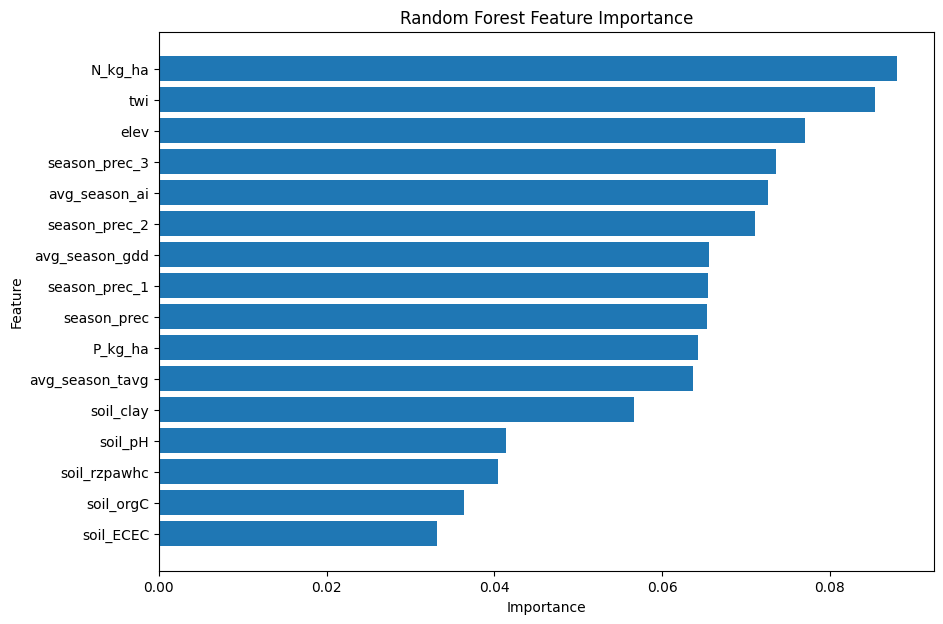

In [56]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 7))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance")
plt.gca().invert_yaxis()

plt.show()

In [57]:
n_estimators=300
class_weight="balanced"

In [59]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier

param_grid = {
    "n_estimators": [300, 500, 700],
    "max_depth": [None, 10, 15, 20, 25],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"],
    "class_weight": ["balanced", "balanced_subsample"]
}

rf_tuned = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)

random_search = RandomizedSearchCV(
    estimator=rf_tuned,
    param_distributions=param_grid,
    n_iter=20,
    scoring="f1_macro",
    cv=3,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

random_search.fit(X_train, y_train)

print("Best parameters:")
print(random_search.best_params_)

print()
print("Best cross-validation macro F1:")
print(random_search.best_score_)

Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best parameters:
{'n_estimators': 500, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'max_depth': 10, 'class_weight': 'balanced'}

Best cross-validation macro F1:
0.45468300870294115


In [60]:
# Get the best model found during tuning
best_rf = random_search.best_estimator_

# Predict on the untouched test data
y_pred_tuned = best_rf.predict(X_test)

print("Tuned model predictions completed.")

Tuned model predictions completed.


In [61]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

accuracy_tuned = accuracy_score(y_test, y_pred_tuned)

print("Tuned Model Accuracy:", accuracy_tuned)
print()

print("Tuned Model Classification Report:")
print(
    classification_report(
        y_test,
        y_pred_tuned,
        labels=[
            "Unsuitable",
            "Moderately Suitable",
            "Suitable"
        ],
        zero_division=0
    )
)

cm_tuned = confusion_matrix(
    y_test,
    y_pred_tuned,
    labels=[
        "Unsuitable",
        "Moderately Suitable",
        "Suitable"
    ]
)

print("Tuned Model Confusion Matrix:")
print(cm_tuned)

Tuned Model Accuracy: 0.6031894934333959

Tuned Model Classification Report:
                     precision    recall  f1-score   support

         Unsuitable       0.26      0.23      0.24        92
Moderately Suitable       0.30      0.38      0.33       244
           Suitable       0.78      0.73      0.75       730

           accuracy                           0.60      1066
          macro avg       0.45      0.44      0.44      1066
       weighted avg       0.63      0.60      0.61      1066

Tuned Model Confusion Matrix:
[[ 21  43  28]
 [ 32  92 120]
 [ 28 172 530]]


In [62]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

print("\nTest class distribution:")
print(y_test.value_counts())

X_train: (4263, 16)
X_test: (1066, 16)
y_train: (4263,)
y_test: (1066,)

Test class distribution:
suitability
Suitable               730
Moderately Suitable    244
Unsuitable              92
Name: count, dtype: int64


In [63]:
print("model_data:", model_data.shape)
print("X:", X.shape)
print("y:", y.shape)

model_data: (5329, 18)
X: (5329, 16)
y: (5329,)


In [64]:
print(model_data["suitability"].value_counts())

suitability
Suitable               3648
Moderately Suitable    1222
Unsuitable              459
Name: count, dtype: int64


In [65]:
print(X.isnull().sum().sum())
print(y.isnull().sum())

0
0


In [66]:
print(model_data.head())
print()
print(model_data.columns.tolist())

   avg_season_gdd  avg_season_ai  avg_season_tavg  season_prec  season_prec_1  \
0     2509.099854       0.998492        21.275661   677.039708     228.759519   
1     2552.900146       1.038017        21.507408   760.532583     154.624451   
2     2580.099854       1.008526        21.651323   724.153837     181.676820   
3     2562.800049       1.018445        21.559790   998.342599     379.451999   
4     2612.800049       1.023641        21.824339   998.342599     379.451999   

   season_prec_2  season_prec_3  elev        twi  soil_rzpawhc  soil_clay  \
0     365.227443      83.052746  1280   8.322142         120.0       34.0   
1     464.134379     141.773752  1288  10.117007         120.0       38.0   
2     359.354439     183.122578  1243   7.909871         120.0       33.0   
3     428.776234     190.114366  1271   8.969049         120.0       32.0   
4     428.776234     190.114366  1226   6.008638         120.0       33.0   

   soil_pH  soil_orgC  soil_ECEC    N_kg_ha   P_kg

In [67]:
print("Original data:", data.shape)
print("model_data:", model_data.shape)

Original data: (6095, 47)
model_data: (5329, 18)


In [69]:
# Reload the original dataset
original_data = pd.read_csv(
    "One_Acre_Fund_MEL_maize_survey_data_2016-2022.csv"
)

print("Original dataset shape:", original_data.shape)

Original dataset shape: (14773, 46)


In [71]:
print(original_data.columns.tolist())

['year', 'lon', 'lat', 'strat', 'avg_season_gdd', 'avg_season_ai', 'avg_season_tavg', 'season_prec', 'season_prec_1', 'season_prec_2', 'season_prec_3', 'elev', 'twi', 'soil_rzpawhc', 'soil_clay', 'soil_pH', 'soil_orgC', 'soil_ECEC', 'plant_date_dev', 'pl_m2', 'row_spacing', 'hybrid', 'hyb_type', 'hyb_mat', 'hyb_yor', 'hyb_tol_mln', 'hyb_tol_msv', 'hyb_tol_gls', 'hyb_tol_nclb', 'hyb_tol_rust', 'hyb_tol_ear_rot', 'N_kg_ha', 'P_kg_ha', 'K_kg_ha', 'compost', 'comp_kg_ha', 'manure', 'fert_in_hole', 'lime_kg_ha', 'weeding', 'pesticide', 'disease', 'pest', 'striga', 'water_excess', 'yield_kg_ha']


In [72]:
features = [
    "avg_season_gdd",
    "avg_season_ai",
    "avg_season_tavg",
    "season_prec",
    "season_prec_1",
    "season_prec_2",
    "season_prec_3",
    "elev",
    "twi",
    "soil_rzpawhc",
    "soil_clay",
    "soil_pH",
    "soil_orgC",
    "soil_ECEC",
    "N_kg_ha",
    "P_kg_ha"
]

# Create modelling dataset from the original data
model_data = original_data[features + ["yield_kg_ha"]].dropna()

# Create suitability target
model_data["suitability"] = pd.cut(
    model_data["yield_kg_ha"],
    bins=[-float("inf"), 1000, 2000, float("inf")],
    labels=[
        "Unsuitable",
        "Moderately Suitable",
        "Suitable"
    ]
)

print("Model data shape:", model_data.shape)
print()
print("Suitability distribution:")
print(model_data["suitability"].value_counts())

Model data shape: (10310, 18)

Suitability distribution:
suitability
Suitable               7253
Moderately Suitable    2155
Unsuitable              902
Name: count, dtype: int64


In [73]:
from sklearn.model_selection import train_test_split

# Input features
X = model_data[features]

# Target variable
y = model_data["suitability"]

# 80/20 stratified split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (8248, 16)
X_test: (2062, 16)
y_train: (8248,)
y_test: (2062,)


In [74]:
print("\nTraining distribution:")
print(y_train.value_counts())

print("\nTesting distribution:")
print(y_test.value_counts())


Training distribution:
suitability
Suitable               5802
Moderately Suitable    1724
Unsuitable              722
Name: count, dtype: int64

Testing distribution:
suitability
Suitable               1451
Moderately Suitable     431
Unsuitable              180
Name: count, dtype: int64


In [75]:
from sklearn.ensemble import RandomForestClassifier

best_rf = RandomForestClassifier(
    n_estimators=500,
    max_depth=10,
    min_samples_split=2,
    min_samples_leaf=4,
    max_features="sqrt",
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

best_rf.fit(X_train, y_train)

print("Final tuned Random Forest training completed.")

Final tuned Random Forest training completed.


In [76]:
# Make predictions on the test data
y_pred_final = best_rf.predict(X_test)

print("Predictions completed.")


Predictions completed.


In [77]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

# Accuracy
accuracy_final = accuracy_score(y_test, y_pred_final)

print("Final Model Accuracy:", accuracy_final)
print()

# Classification report
print("Final Model Classification Report:")
print(
    classification_report(
        y_test,
        y_pred_final,
        labels=[
            "Unsuitable",
            "Moderately Suitable",
            "Suitable"
        ],
        zero_division=0
    )
)

# Confusion matrix
cm_final = confusion_matrix(
    y_test,
    y_pred_final,
    labels=[
        "Unsuitable",
        "Moderately Suitable",
        "Suitable"
    ]
)

print("Final Model Confusion Matrix:")
print(cm_final)

Final Model Accuracy: 0.6420950533462657

Final Model Classification Report:
                     precision    recall  f1-score   support

         Unsuitable       0.32      0.43      0.37       180
Moderately Suitable       0.33      0.41      0.37       431
           Suitable       0.83      0.74      0.78      1451

           accuracy                           0.64      2062
          macro avg       0.49      0.53      0.51      2062
       weighted avg       0.68      0.64      0.66      2062

Final Model Confusion Matrix:
[[  78   52   50]
 [  85  176  170]
 [  80  301 1070]]


In [78]:
# Get prediction probabilities
y_prob = best_rf.predict_proba(X_test)

print("Probability shape:", y_prob.shape)
print()
print("Classes:")
print(best_rf.classes_)


Probability shape: (2062, 3)

Classes:
['Moderately Suitable' 'Suitable' 'Unsuitable']


In [79]:
# Display probabilities for the first 10 test observations

probability_df = pd.DataFrame(
    y_prob,
    columns=best_rf.classes_
)

probability_df["Predicted"] = y_pred_final

probability_df.head(10)

,Moderately Suitable,Suitable,Unsuitable,Predicted
0,0.414886,0.304763,0.280352,Moderately Suitable
1,0.319268,0.544552,0.136181,Suitable
2,0.402501,0.504912,0.092587,Suitable
3,0.413781,0.285376,0.300844,Moderately Suitable
4,0.211493,0.632969,0.155538,Suitable
5,0.226899,0.636324,0.136777,Suitable
6,0.290655,0.549567,0.159778,Suitable
7,0.286774,0.150440,0.562786,Unsuitable
8,0.301531,0.520888,0.177581,Suitable
9,0.230434,0.679746,0.089820,Suitable


In [80]:
def predict_maize_suitability(input_data):
    """
    Predict maize suitability for a single field.

    input_data must contain the same 16 features
    used during model training.
    """

    # Convert input into a DataFrame
    input_df = pd.DataFrame([input_data])

    # Get predicted class
    prediction = best_rf.predict(input_df)[0]

    # Get class probabilities
    probabilities = best_rf.predict_proba(input_df)[0]

    # Find probability belonging to predicted class
    predicted_index = list(best_rf.classes_).index(prediction)
    confidence = probabilities[predicted_index]

    return {
        "suitability": prediction,
        "confidence": round(confidence * 100, 2)
    }

In [81]:
# Take the first test observation
sample_field = X_test.iloc[0].to_dict()

result = predict_maize_suitability(sample_field)

print(result)

{'suitability': 'Moderately Suitable', 'confidence': np.float64(41.49)}


Confusion Matrix:
[[ 176  170   85]
 [ 301 1070   80]
 [  52   50   78]]


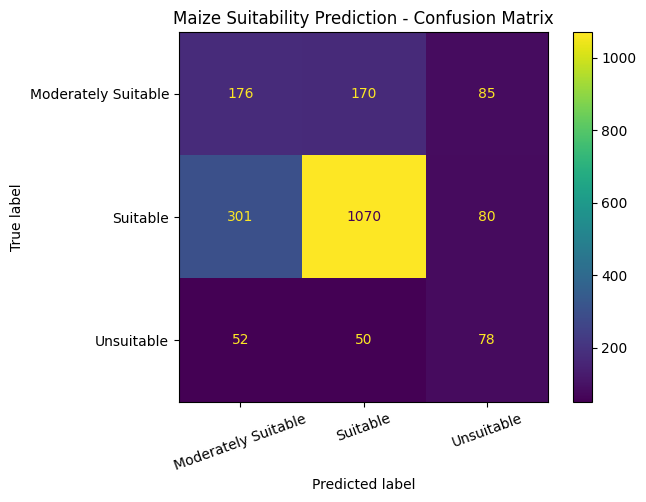

In [82]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Make predictions
y_pred = best_rf.predict(X_test)

# Create confusion matrix
cm = confusion_matrix(y_test, y_pred, labels=best_rf.classes_)

print("Confusion Matrix:")
print(cm)

# Display it
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=best_rf.classes_
)

disp.plot()
plt.title("Maize Suitability Prediction - Confusion Matrix")
plt.xticks(rotation=20)
plt.show()

In [83]:
best_rf.classes_


array(['Moderately Suitable', 'Suitable', 'Unsuitable'], dtype=object)

In [84]:
import pandas as pd
import matplotlib.pyplot as plt

feature_importance = pd.DataFrame({
    "Feature": features,
    "Importance": best_rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    "Importance",
    ascending=False
)

print(feature_importance)

            Feature  Importance
6     season_prec_3    0.090260
7              elev    0.086930
1     avg_season_ai    0.076671
2   avg_season_tavg    0.076167
14          N_kg_ha    0.075966
5     season_prec_2    0.072981
15          P_kg_ha    0.069951
3       season_prec    0.069315
0    avg_season_gdd    0.069080
4     season_prec_1    0.067386
8               twi    0.059874
10        soil_clay    0.043962
11          soil_pH    0.040865
9      soil_rzpawhc    0.036307
12        soil_orgC    0.034194
13        soil_ECEC    0.030091


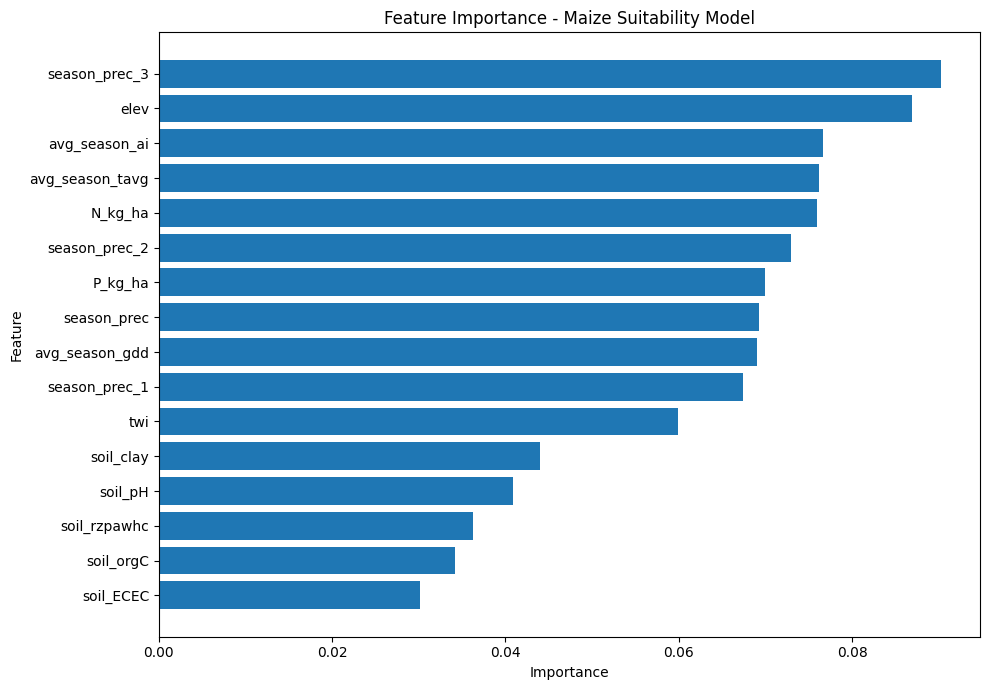

In [85]:
plt.figure(figsize=(10, 7))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Feature Importance - Maize Suitability Model")

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [86]:
import joblib

joblib.dump(best_rf, "maize_suitability_model.pkl")

print("Model saved successfully.")

Model saved successfully.


In [87]:
import os

print(os.path.exists("maize_suitability_model.pkl"))

True


In [88]:
joblib.dump(features, "maize_suitability_features.pkl")

print("Feature list saved successfully.")

Feature list saved successfully.
